/var/folders/cc/nkwtlsz91x7dqc1rw76k6fvw0000gn/T/ipykernel_3895/1059883971.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_region, x="region", y="life_expect", ci="sd")


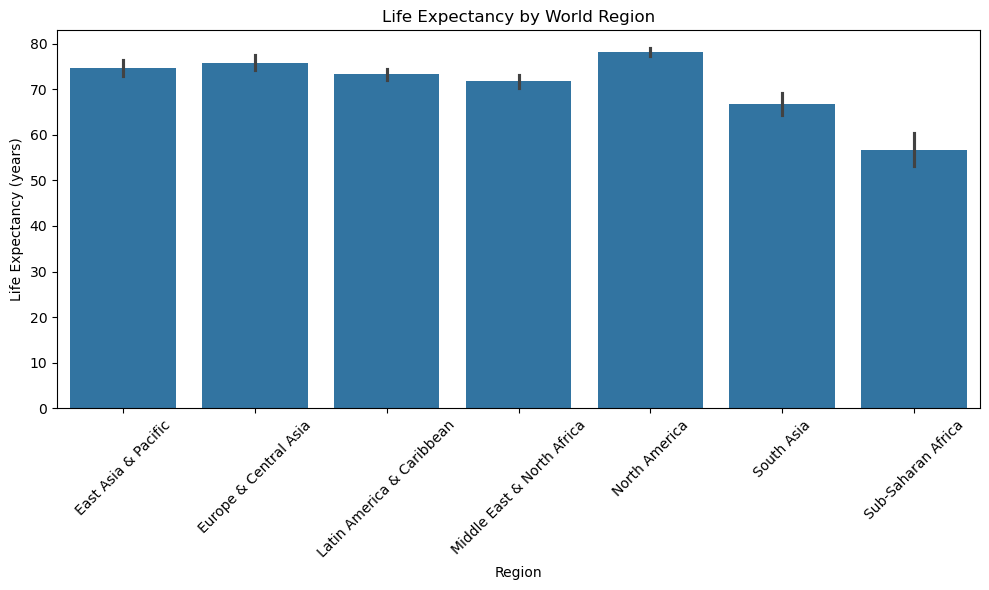

Region T-test: South Asia vs Sub-Saharan Africa — t=11.51, p=0.0000


/var/folders/cc/nkwtlsz91x7dqc1rw76k6fvw0000gn/T/ipykernel_3895/1059883971.py:48: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_income, x="income_level", y="life_expect", ci="sd")


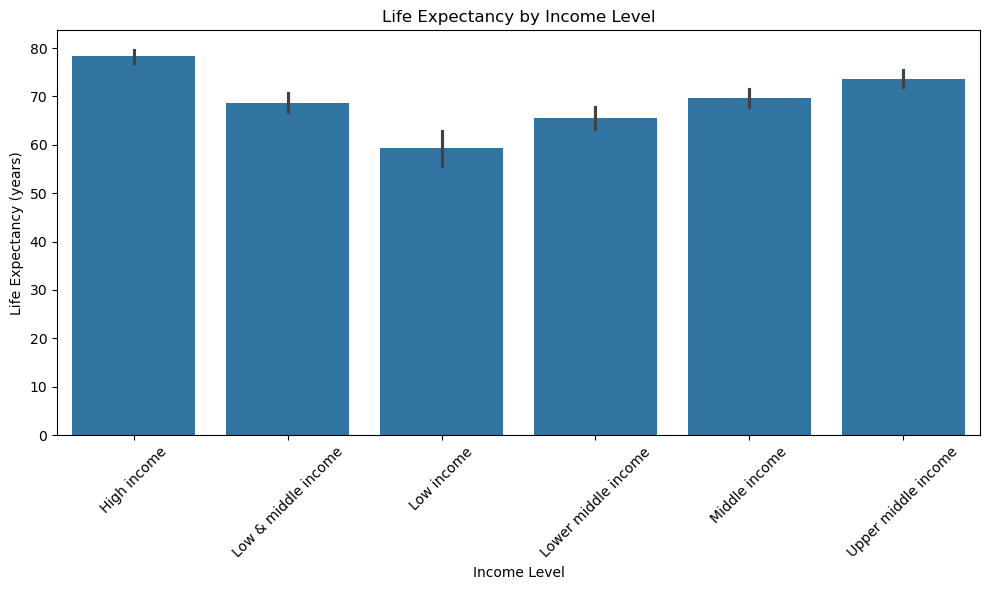

Income T-test: High vs Low & Middle — t=20.39, p=0.0000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Load the cleaned dataset
df = pd.read_csv("cleaned_world_health_data.csv")

# Define labels
world_regions = [
    "East Asia & Pacific", "Europe & Central Asia", "Latin America & Caribbean",
    "Middle East & North Africa", "North America", "South Asia", "Sub-Saharan Africa"
]

income_levels = [
    "Low income", "Lower middle income", "Low & middle income", "Middle income",
    "Upper middle income", "High income"
]

# ----------------------------------
# Plot 1: Barplot + T-test by Region
# ----------------------------------
df_region = df[df["country"].isin(world_regions)].copy()
df_region["region"] = df_region["country"]

plt.figure(figsize=(10, 6))
sns.barplot(data=df_region, x="region", y="life_expect", ci="sd")
plt.title("Life Expectancy by World Region")
plt.xlabel("Region")
plt.ylabel("Life Expectancy (years)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Example T-test: South Asia vs. Sub-Saharan Africa
group1 = df_region[df_region["region"] == "South Asia"]["life_expect"]
group2 = df_region[df_region["region"] == "Sub-Saharan Africa"]["life_expect"]
t_stat, p_val = ttest_ind(group1, group2, equal_var=False, nan_policy="omit")
print(f"Region T-test: South Asia vs Sub-Saharan Africa — t={t_stat:.2f}, p={p_val:.4f}")

# ----------------------------------
# Plot 2: Barplot + T-test by Income
# ----------------------------------
df_income = df[df["country"].isin(income_levels)].copy()
df_income["income_level"] = df_income["country"]

plt.figure(figsize=(10, 6))
sns.barplot(data=df_income, x="income_level", y="life_expect", ci="sd")
plt.title("Life Expectancy by Income Level")
plt.xlabel("Income Level")
plt.ylabel("Life Expectancy (years)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Example T-test: High income vs. Low & middle income
group1 = df_income[df_income["income_level"] == "High income"]["life_expect"]
group2 = df_income[df_income["income_level"] == "Low & middle income"]["life_expect"]
t_stat, p_val = ttest_ind(group1, group2, equal_var=False, nan_policy="omit")
print(f"Income T-test: High vs Low & Middle — t={t_stat:.2f}, p={p_val:.4f}")